### Load dataset

In [1]:
from sklearn.model_selection import train_test_split

from src.plotting import plt_sample
from src.dataset import load_preprocessed_dataset


x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=1,
)
x_test = x_test.cpu()
# SAMPLE_IDX = 0
# plt_sample(x_train[SAMPLE_IDX].squeeze(), y_train[SAMPLE_IDX])

### Train model

In [ ]:
import torch
from torch import nn, Tensor
from monai.networks.nets import SwinUNETR, UNet

from src.training import train_unet
from src.dataset import get_data_loaders
from src.metrics import SegmentationLoss
from src.configs import TrainingConfig, ModelConfig


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_cfg = TrainingConfig()
model_cfg = ModelConfig()
def mk_model(train_cfg: TrainingConfig, model_cfg: ModelConfig) -> nn.Module:
    model = (
        UNet(
            spatial_dims=2,
            in_channels=1,
            out_channels=train_cfg.n_classes,
            channels=model_cfg.channels,
            strides=model_cfg.strides,
            kernel_size=model_cfg.kernel_size,
            num_res_units=model_cfg.num_res_units,
            act=model_cfg.act,
            norm=model_cfg.norm,
            dropout=model_cfg.dropout,
            bias=model_cfg.bias,
        )
        .to(device)
    )
    model.cfg = model_cfg
    return model

model = mk_model(train_cfg, model_cfg)
# train_loader, valid_loader = get_data_loaders(
#     x_train,
#     y_train,
#     x_valid,
#     y_valid,
#     batch_size=train_cfg.batch_size,
# )
# cirterion = SegmentationLoss(train_cfg)
# train_unet(
#     model,
#     train_cfg,
#     train_loader,
#     valid_loader,
#     cirterion,
#     save_checkpoint=True,
#     plt_preds=True,
#     x_test=x_test,
# )
# del train_loader
# del valid_loader
# del model

number of parameters: 1.0M


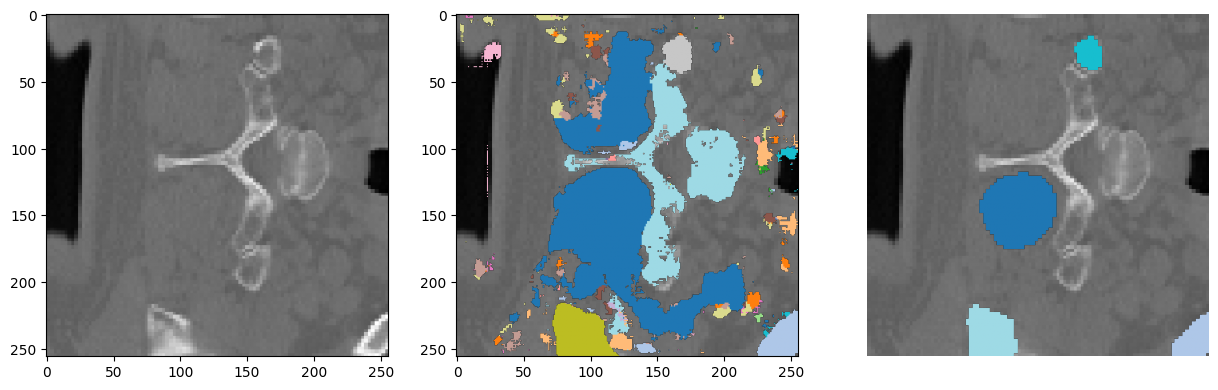

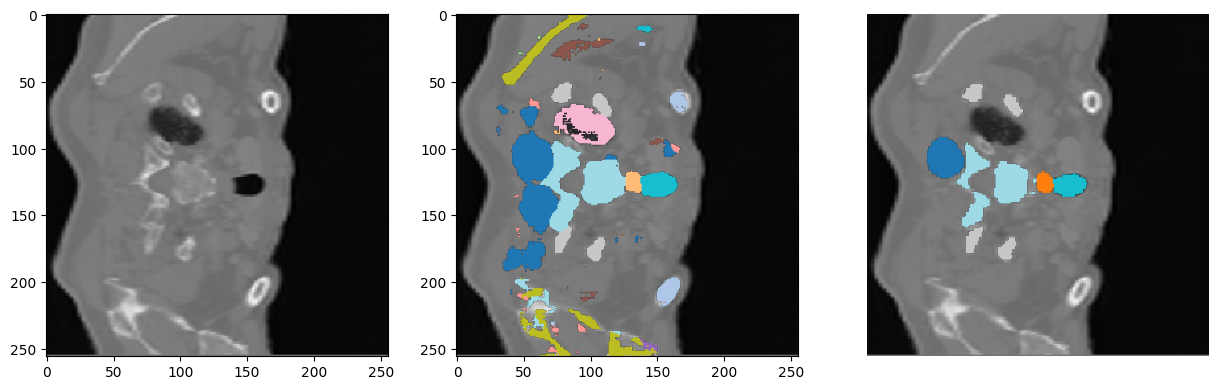

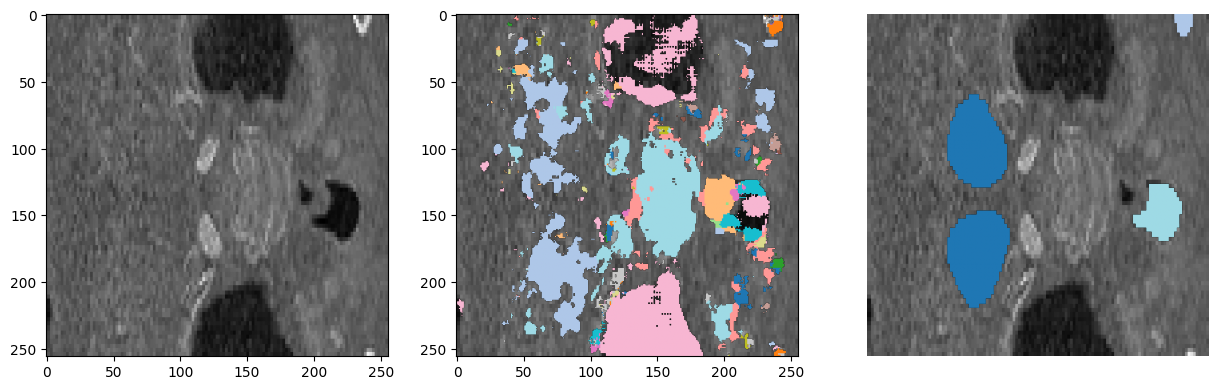

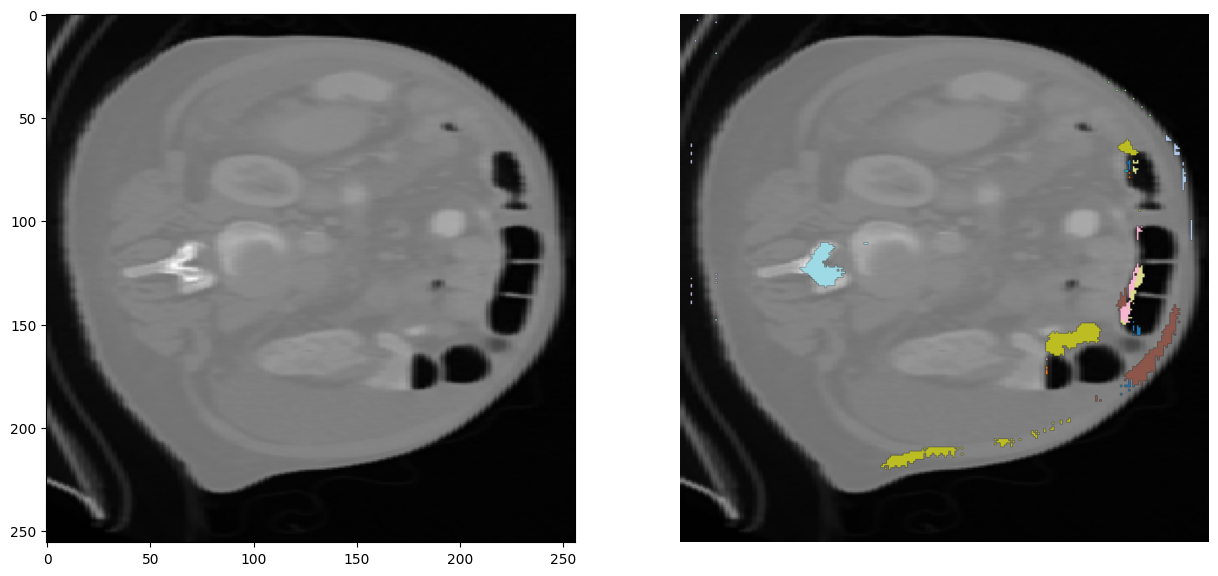

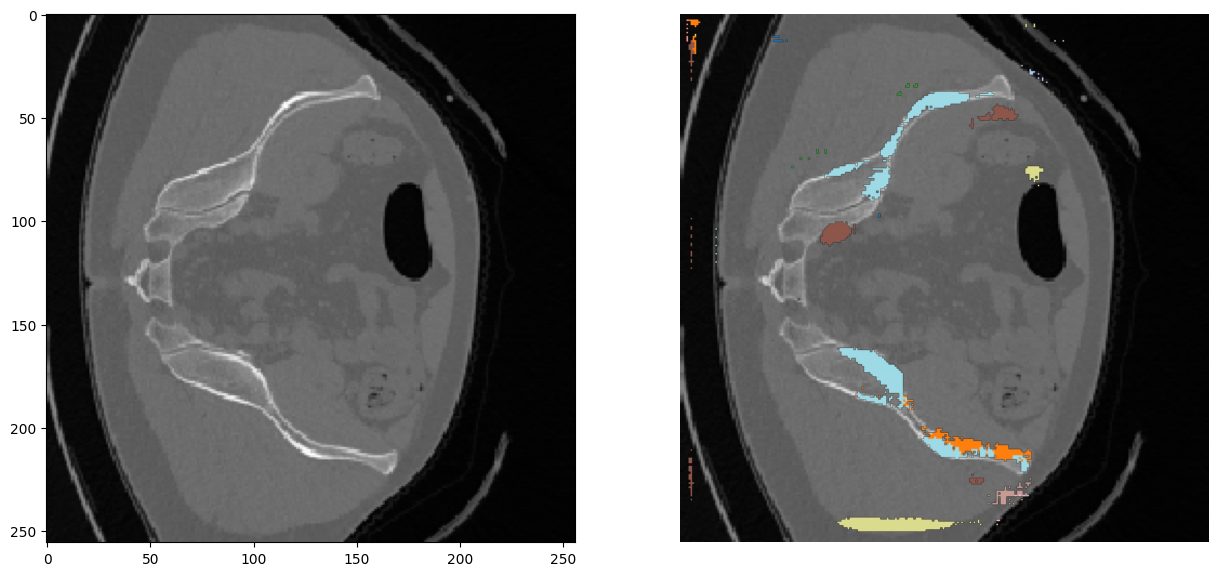

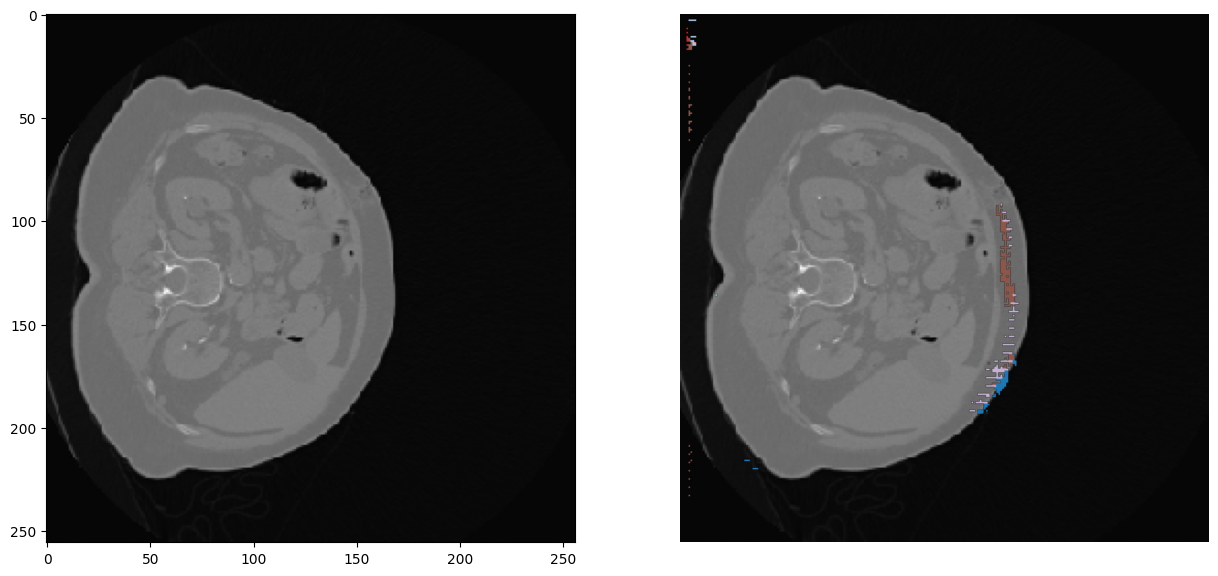

In [3]:
import numpy as np

from src.plotting import plt_pred


model_weights = torch.load(
    f'checkpoints/checkpoint_epoch{61}.pth',
    weights_only=True,
)
model = mk_model(train_cfg, model_cfg).eval()
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print("number of parameters:", str(params // 1e6) + "M")
model.load_state_dict(model_weights)
plt_pred(model, 100, x_train, y_train)
plt_pred(model, 120, x_train, y_train)
plt_pred(model, 12, x_valid, y_valid)
plt_pred(model, 7, x_test)
plt_pred(model, 8, x_test)
plt_pred(model, 81, x_test)

### Make submission

In [4]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader


@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=16):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)
    predictions = []

    for image in tqdm(test_loader) :
        image = image.to(device=device)
        y_pred_logits = model(image)
        pred = torch.argmax(y_pred_logits, dim=1)
        predictions.append(pred.cpu().numpy())

    predictions = np.array(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T
    df.index = [f"Pixel {i}" for i in df.index]
    df.columns = [f"{col}.png" for col in df.columns]
    df.to_csv("submission.csv")
# 
mk_submission(model, x_test)

100%|██████████| 125/125 [00:08<00:00, 14.44it/s]


n unique values: 52
